# Global mean timeseries: raw input vs. downscaled output

Extends [Input-data global mean timeseries](./input-data-global-timeseries.ipynb) (same
area-weighted global-annual-mean reduction, same per-GCM panel layout) by overlaying the
**v0.14.1 downscaled production output** on top of the raw-GCM/ERA5 lines it already draws --
for every QA variable, not just `tas`.

The raw-GCM reduction and its coverage guards are unchanged from the original notebook; see
that notebook for the full rationale (junction defects, coverage/n_days guards, etc.). This
notebook adds:

- A second reduction, over the downscaled production tree (`discover_leaves`/`get_data` from
  `srm.qa_flags`, not `catalog.get(gcm).to_xarray()` -- downscaled output is organized as
  `{method}/{scenario}/{variable}/{ensemble_member}` **groups**, one leaf per member, unlike the
  raw input's `{scenario}` group with an `ensemble_member` **dimension**).
- The same reduction function (`global_annual_mean`) applied to both, so raw and downscaled
  numbers are directly comparable -- no separate downscaled-specific methodology.
- One run per variable in `VARIABLES`, not a single hardcoded `tas`.
- `bcsd` and `qdmsd` overlaid on the same panel, distinguished by linestyle; each downscaled
  ensemble draws the same thin-member/thick-ensemble-mean pair the raw side does, at
  `DOWNSCALED_ALPHA` opacity throughout so raw stays legible where the two families overlap.

MIROC-ES2H is dropped from `GCMS` here (present in the raw-only original): there is no v0.14.1
downscaled production output for it to overlay, so every panel in this notebook has both a raw
and a downscaled line to compare.

This notebook does not carry over the original's Section 5 (step-change detection at scenario
junctions) or Section 6 (its written findings from one specific past investigation) -- those are
about the raw input data specifically and are answered in the original notebook already; ask if
you want that analysis re-run per variable here too.

In [2]:
import os
import pathlib

import coiled
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask_array.xarray import register
from matplotlib.lines import Line2D
from srm.config import GROUP_TO_SCENARIO, ClusterConfig
from srm.datasets import catalog
from srm.qa_flags import discover_leaves, get_data, parse_tag

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
# The reduction and the plotting are written against a variable name, looped over below --
# re-running this for a different variable set is a one-line change to VARIABLES.
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]
# MIROC-ES2H dropped vs. the original (raw-only) notebook: there is no v0.14.1 downscaled
# production output for it, so it would have no downscaled line to overlay.
GCMS = ["CESM2-WACCM6", "UKESM1-1-LL"]
METHODS = ["bcsd", "qdmsd"]
SPATIAL = ["lat", "lon"]

# ERA5 is the bias-correction target, so it is the reference the historical period should track.
# The store covers 1950-2014 only, and reading it adds roughly 100 GB to the total.
INCLUDE_ERA5 = True

# A year is plotted only if the store holds at least this fraction of a calendar year of days for
# it, and if at least this fraction of the globe by area was non-NaN. Section 3 explains why both
# guards are needed. Applied identically to the raw and downscaled reductions.
MIN_DAY_FRACTION = 0.9
MIN_AREA_COVERAGE = 0.99

# Where to read the v0.14.1 downscaled production output from -- same convention used throughout
# the QA notebooks (discover_leaves/get_data in src/srm/qa_flags.py).
DS_BRANCH = "v1.0.0"
DS_ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
DS_STORE_SUBSET_ID = "global"

# Scenario colors are a validated categorical palette rather than hand-picked ones. Blue, orange,
# aqua and violet clear the all-pairs check on a light surface (worst CVD dE 9.2 under simulated
# protanopia/deuteranopia, worst normal-vision dE 16.3). The explainer-derived set they replace did
# not: it gave esgf_ssp245 and ssp245 the same hex, and its navy sat below the mark lightness band,
# so it collided with the black ERA5 line. Aqua also reads as the cooled scenario against orange.
SURFACE = "#fcfcfb"
SCENARIO_STYLE = {
    "historical": {"color": "#2a78d6", "linestyle": "-"},
    "ssp245": {"color": "#eb6834", "linestyle": "-"},
    # MIROC's ESGF-archive SSP245, covering the years before the GeoMIP baseline. It takes its own
    # hue rather than a dashed SSP245, because the two are compared directly in the MIROC panel.
    "esgf_ssp245": {"color": "#4a3aa7", "linestyle": "--"},
    # Aqua sits at 2.74:1 against the surface, just under the 3:1 target, so the figures carry
    # direct labels and the junction tables repeat the same values as the required relief channel.
    "g6_1p5k": {"color": "#1baf7a", "linestyle": "-"},
    # The termination-shock continuation of g6_1p5k member 002 (2085-2100). It reuses the hue of
    # the run it continues rather than taking a fifth categorical slot: it is the same experiment,
    # a later segment, and the two are time-disjoint so they never compete on the x axis. Dotted
    # marks the post-termination years, and the validated four-hue palette stands unchanged.
    "g6_1p5k_end": {"color": "firebrick", "linestyle": "-"},
}
# ERA5 is a reference rather than a scenario, so it stays a neutral dashed line and does not
# consume a categorical slot.
OBS_STYLE = {"color": "#0b0b0b", "linestyle": "-"}
# Downscaled lines reuse the scenario's own color (so raw and downscaled are directly comparable
# by hue) but override linestyle by method rather than by scenario, since scenario is already
# carried by color and the raw line already owns the scenario's own linestyle. Chosen to not
# collide with any SCENARIO_STYLE linestyle above ("-", "--", ":").
METHOD_LINESTYLE = {"bcsd": "-", "qdmsd": (0, (3, 1, 1, 1))}
# Reserved status colors, kept distinct from the scenario slots so a flag never impersonates a
# series. They are always paired with a text label, never carrying meaning by color alone.
STATUS_CRITICAL, STATUS_NEUTRAL, INK = "#d03b3b", "#8a8a86", "#52514e"
GROUPS = list(SCENARIO_STYLE)


def cache_path(kind: str, variable: str) -> pathlib.Path:
    """Cache location for one reduction: raw or downscaled, one file per variable.

    Set to a path that doesn't exist (or delete the file) to force a recompute.
    """
    return pathlib.Path.home() / ".cache" / "srm" / f"global-annual-mean-{kind}-{variable}.csv"

## 1. Compute

The reduction returns a few thousand floats, so the entire cost is the read: about 360 GB from S3
in `us-west-2`, being the 264 GB of GCM stores inventoried in section 2 plus roughly 100 GB of
ERA5. Cluster settings follow `srm.config.ClusterConfig`.

- `register()` activates frisky's dask array backend for xarray. It must run **before any store is
  opened**, or a later compute raises `Mixing chunked array types`.
- `hijack()` wraps the client so progress stays visible through a read this long.
- Nothing is persisted. Under frisky a `persist` gathers the result to the client, which overflows
  the websocket proxy buffer at this size, so every intermediate stays lazy.

In [2]:
# The raw-GCM read volume is the same ~250 GB the original notebook inventories (section 2), but
# this notebook also reads the downscaled production output for 2 GCMs x 2 methods x up to 4
# scenarios x every variable in VARIABLES -- downscaled output is on a much finer native grid than
# the raw GCM inputs (see flag_step*'s 0.25deg fine grid vs. the ~1-2deg GCM grids in section 2's
# inventory), so despite far fewer ensemble members per (gcm, scenario), the total read volume is
# comparable to or larger than the raw side. Sized up from the original's n_workers=20 accordingly.
#
# Use a FIXED pool, not an adaptive one. Each group reduces in one long pass, so a worker that
# vanishes mid-run discards reduction partials that frisky surfaces as an unrecoverable "missing
# dependencies" invariant violation rather than recomputing. A fixed worker count removes adaptive
# downscaling, which is one of the two ways a worker vanishes; uncomment spot_policy="on-demand"
# to remove the other.
cfg = ClusterConfig(
    n_workers=28,
    worker_vm_types=["r8g.4xlarge"],
    scheduler_vm_types=["r8g.xlarge"],
    # spot_policy="on-demand",
)
cluster = coiled.Cluster(
    name="srm-qa-global-mean-comparison",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
)
client = hijack(cluster.get_client())
client

[2026-09-10 00:48:39,925][INFO    ][coiled] Fetching latest package priorities...
[2026-09-10 00:48:39,926][INFO    ][coiled.package_sync] Resolving your local /Users/clairezarakas/Documents/TEMPORARY_TO_DELETE/srm-downscaling/uv.lock Python environment...
[2026-09-10 00:48:40,032][INFO    ][coiled.package_sync] Scanning 290 python packages...
[2026-09-10 00:48:40,225][INFO    ][coiled] Running pip check...
[2026-09-10 00:48:40,463][INFO    ][coiled] Validating environment...
[2026-09-10 00:48:41,138][INFO    ][coiled] Creating wheel for ~/Documents/TEMPORARY_TO_DELETE/srm-downscaling/src...
[2026-09-10 00:48:41,220][INFO    ][coiled] Creating wheel for srm...
[2026-09-10 00:48:42,757][INFO    ][coiled] Uploading coiled_local_src...
[2026-09-10 00:48:43,740][INFO    ][coiled] Uploading srm...
[2026-09-10 00:48:44,698][INFO    ][coiled] Creating software environment...
[2026-09-10 00:48:46,156][INFO    ][coiled] Creating Cluster (name: srm-qa-global-mean-comparison, https://cloud.coiled

<frisky.Client: scheduler="wss://cluster-demrn.dask.host/SbUj2lIk2Ynj5KTy/frisky-comm?__frisky_dial_host=34.219.156.61" id="client-0">

## 2. The input store layout

One icechunk store per GCM under `s3://carbonplan-srm/input/processed/`, in zarr groups keyed by
scenario. Input and output stores nest ensemble members differently, which matters when adapting
code from [Output integrity checks](./output-integrity-checks.ipynb):

| | Input stores | Output stores |
|---|---|---|
| Layout | `{scenario}` group, `ensemble_member` **dimension** | `{scenario}/{variable}/{member}` **groups** |
| Select a member | `dt["ssp245"].tas.sel(ensemble_member="003")` | `tree["ssp245/tas/003"]` |

The inventory below reads coordinates only. Its `read_gb` column is what section 3 pulls through
the cluster, before the ERA5 read that `INCLUDE_ERA5` adds on top.

In [3]:
trees = {gcm: catalog.get(gcm).to_xarray() for gcm in GCMS}


def inventory_rows(gcm: str, tree: xr.DataTree) -> list[dict]:
    """One row per (gcm, group, variable) present, from coordinates alone."""
    rows = []
    for group in tree.children:
        ds = tree[group].to_dataset()
        time = pd.DatetimeIndex(ds.time.values)
        n_members = ds.sizes.get("ensemble_member", 1)
        cells = ds.sizes["lat"] * ds.sizes["lon"]
        for var in VARIABLES:
            if var not in ds.data_vars:
                continue
            rows.append(
                {
                    "gcm": gcm,
                    "group": group,
                    "scenario": GROUP_TO_SCENARIO.get(group, group),
                    "variable": var,
                    "members": n_members,
                    "start": time[0].date(),
                    "end": time[-1].date(),
                    "n_days": len(time),
                    "grid": f"{ds.sizes['lat']} x {ds.sizes['lon']}",
                    "read_gb": round(n_members * len(time) * cells * 4 / 1e9, 1),
                }
            )
    return rows


inventory = pd.DataFrame(
    [row for gcm, tree in trees.items() for row in inventory_rows(gcm, tree)]
).sort_values(["gcm", "group", "variable"], ignore_index=True)
print(f"total to read (raw, {len(VARIABLES)} variables): {inventory.read_gb.sum():.0f} GB")
inventory

total to read (raw, 5 variables): 792 GB


,gcm,group,scenario,variable,members,start,end,n_days,grid,read_gb
0,CESM2-WACCM6,g6_1p5k,G6-1.5K,pr,3,2035-01-01,2084-12-31,18263,192 x 288,12.1
1,CESM2-WACCM6,g6_1p5k,G6-1.5K,rsds,3,2035-01-01,2084-12-31,18263,192 x 288,12.1
2,CESM2-WACCM6,g6_1p5k,G6-1.5K,tas,3,2035-01-01,2084-12-31,18263,192 x 288,12.1
3,CESM2-WACCM6,g6_1p5k,G6-1.5K,tasmax,3,2035-01-01,2084-12-31,18263,192 x 288,12.1
4,CESM2-WACCM6,g6_1p5k,G6-1.5K,tasmin,3,2035-01-01,2084-12-31,18263,192 x 288,12.1
5,CESM2-WACCM6,g6_1p5k_end,g6_1p5k_end,pr,1,2085-01-01,2100-12-31,5843,192 x 288,1.3
6,CESM2-WACCM6,g6_1p5k_end,g6_1p5k_end,rsds,1,2085-01-01,2100-12-31,5843,192 x 288,1.3
7,CESM2-WACCM6,g6_1p5k_end,g6_1p5k_end,tas,1,2085-01-01,2100-12-31,5843,192 x 288,1.3
8,CESM2-WACCM6,g6_1p5k_end,g6_1p5k_end,tasmax,1,2085-01-01,2100-12-31,5843,192 x 288,1.3
9,CESM2-WACCM6,g6_1p5k_end,g6_1p5k_end,tasmin,1,2085-01-01,2100-12-31,5843,192 x 288,1.3


## 3. The reduction

Grid cells shrink toward the poles, so a global mean has to be weighted by cos(lat). We write the
weighted mean out by hand rather than calling `.weighted().mean()`, for two reasons:

- The denominator of the hand-written form, the total weight of non-`NaN` cells, **is** the coverage
  diagnostic. Getting it from `.weighted()` would take a second pass over the data.
- Weights are cast to `float32`. Every array in these stores is `float32`, and a `float64` weight
  promotes each chunk on multiply, doubling the memory the cluster holds for no gain in accuracy.

Two guards accompany the mean, and both are load-bearing:

`coverage`
: Area fraction that was non-`NaN`. Because `NaN` cells drop out of numerator and denominator
  alike, a partially missing year otherwise returns a perfectly plausible number. The g6 `NaN`
  tails in [issue #517](https://github.com/carbonplan/srm-downscaling/issues/517) are this failure
  mode.

`n_days`
: Days the store holds for that year, taken from the time coordinate. It was written against
  CESM2-WACCM, whose `historical` group used to stop on 2015-01-16 and whose `g6_1p5k` group on
  2085-01-01, so that averaging those years as they stood turned a mid-January mean into an annual
  one. [PR #532](https://github.com/carbonplan/srm-downscaling/pull/532) trimmed each CESM group to
  its canonical extent and [PR #533](https://github.com/carbonplan/srm-downscaling/pull/533)
  restamped the CESM time axis from `time_bnds`, so no year fails this guard in the run below. It
  is kept as a regression check on both.

In [4]:
def global_annual_mean(ds: xr.Dataset, var: str) -> xr.Dataset:
    """Lazy area-weighted global annual mean of ``var``, with its coverage diagnostics.

    Parameters
    ----------
    ds : xr.Dataset
        A scenario group, or the flat ERA5 store. Must carry ``lat``, ``lon``, and ``time``; an
        ``ensemble_member`` dimension is carried through if present.
    var : str
        Name of the variable to reduce.

    Returns
    -------
    xr.Dataset
        Indexed by ``year`` (and ``ensemble_member`` where the input has one), with

        ``mean``
            The cos(lat)-weighted global mean, averaged over the days of each year. ``NaN`` cells
            are excluded from numerator and denominator alike, so this is the mean over whatever
            part of the globe holds data.
        ``coverage``
            The area fraction that was non-``NaN``, averaged the same way.
        ``n_days``
            Days present in that year, taken from the time coordinate.
    """
    da = ds[var]
    # float32 weights keep the reduction in the data's own dtype. A float64 weight would silently
    # promote every chunk on multiply and double the memory the cluster has to hold.
    w = np.cos(np.deg2rad(ds.lat)).astype("float32")

    valid_weight = (da.notnull() * w).sum(SPATIAL)
    total_weight = float(w.sum()) * ds.sizes["lon"]

    # Masking the zero denominator keeps an all-NaN day as NaN without an invalid-value warning.
    daily_mean = (da.fillna(0) * w).sum(SPATIAL) / valid_weight.where(valid_weight > 0)
    daily_coverage = valid_weight / total_weight

    n_days = xr.DataArray(
        np.ones(ds.sizes["time"], dtype="int32"),
        coords={"time": ds.time},
        dims="time",
    )

    return xr.Dataset(
        {
            "mean": daily_mean.groupby("time.year").mean(),
            "coverage": daily_coverage.groupby("time.year").mean(),
            "n_days": n_days.groupby("time.year").sum(),
        }
    )

### 3.1 Running it

One `compute` per store group. Each reads that group's array once, with the mean and the coverage
fused into that single pass.

In [5]:
def reduce_group(label: str, group: str, ds: xr.Dataset, variable: str) -> pd.DataFrame:
    """Reduce one store group to a tidy frame of (member, year) rows."""
    result = global_annual_mean(ds, variable).compute()
    df = result.to_dataframe().reset_index()
    if "ensemble_member" not in df.columns:
        df["ensemble_member"] = label
    df.insert(0, "gcm", label)
    df.insert(1, "group", group)
    return df


def reduce_all_raw(variable: str) -> pd.DataFrame:
    """Raw-GCM + ERA5 reduction for one variable, across every gcm in GCMS."""
    frames = []
    for gcm in GCMS:
        tree = trees[gcm]
        for group in GROUPS:
            if group not in tree.children:
                continue
            ds = tree[group].to_dataset()
            if variable not in ds.data_vars:
                continue
            frame = reduce_group(gcm, group, ds, variable)
            frames.append(frame)
            print(f"  raw {gcm}/{group}: {len(frame)} member-years")
    if INCLUDE_ERA5:
        era5 = catalog.get("ERA5").to_xarray()
        if variable in era5.data_vars:
            frames.append(reduce_group("ERA5", "obs", era5, variable))
            print(f"  raw ERA5/obs: {len(frames[-1])} years")
    return pd.concat(frames, ignore_index=True)

### 3.1b Downscaled output

The downscaled production tree is laid out differently from the raw input (section 2's table):
one leaf per `{method}/{scenario}/{variable}/{ensemble_member}` group, discovered via
`discover_leaves`/`get_data` (`src/srm/qa_flags.py`, the same pair every other QA notebook in this
repo uses) rather than `catalog.get(gcm).to_xarray()`. Each leaf is already a single member --
there is no `ensemble_member` dimension to reduce over the way the raw side's `reduce_group` does
-- so `reduce_group` isn't reused directly here; the real member id comes from `parse_tag`, not
from a synthetic per-group label.

`global_annual_mean` itself is unchanged: it only needs `lat`/`lon`/`time` on whatever `xr.Dataset`
it's handed, so the same function applies to a downscaled tag's fine-grid data exactly as it does
to a raw GCM's coarse-grid data.

In [6]:
def reduce_downscaled_tag(tag: str, trees_ds: dict, variable: str) -> pd.DataFrame:
    """Reduce one downscaled leaf (one gcm/scenario/method/member) to a tidy frame of year rows."""
    gcm, _var, scenario, member, method = parse_tag(tag)
    da = get_data(tag=tag, trees=trees_ds, is_downscaled=True, var_to_analyze=variable)
    ds = da.to_dataset(name=variable)
    result = global_annual_mean(ds, variable).compute()
    df = result.to_dataframe().reset_index()
    df.insert(0, "gcm", gcm)
    df.insert(1, "group", scenario)
    df.insert(2, "method", method)
    df["ensemble_member"] = member
    return df


def reduce_all_downscaled(variable: str) -> pd.DataFrame:
    """Downscaled reduction for one variable, across every (gcm, method) in GCMS x METHODS."""
    ds_trees, ds_tags, gcms_np, scenarios_np, variables_np, tags_np, methods_np, _dcf_np = (
        discover_leaves(
            gcms=GCMS,
            branch=DS_BRANCH,
            root_dir=DS_ROOT_DIR,
            store_subset_id=DS_STORE_SUBSET_ID,
            is_downscaled=True,
        )
    )
    frames = []
    for gcm in GCMS:
        for method in METHODS:
            tags = tags_np[(gcms_np == gcm) & (variables_np == variable) & (methods_np == method)]
            if len(tags) == 0:
                print(f"  downscaled {gcm}/{method}: no leaves for {variable!r}")
                continue
            for tag in tags:
                frame = reduce_downscaled_tag(tag, ds_trees, variable)
                frames.append(frame)
            print(
                f"  downscaled {gcm}/{method}: {len(tags)} leaves, {sum(len(f) for f in frames[-len(tags) :])} member-years"
            )
    if not frames:
        return pd.DataFrame(
            columns=[
                "gcm",
                "group",
                "method",
                "year",
                "mean",
                "coverage",
                "n_days",
                "ensemble_member",
            ]
        )
    return pd.concat(frames, ignore_index=True)

In [7]:
annual_by_variable: dict[str, pd.DataFrame] = {}
downscaled_by_variable: dict[str, pd.DataFrame] = {}

for variable in VARIABLES:
    print(f"=== {variable} ===")

    raw_path = cache_path("raw", variable)
    if raw_path.exists():
        annual_by_variable[variable] = pd.read_csv(raw_path)
        print(f"  raw: loaded {len(annual_by_variable[variable])} rows from {raw_path}")
    else:
        annual_by_variable[variable] = reduce_all_raw(variable)
        raw_path.parent.mkdir(parents=True, exist_ok=True)
        annual_by_variable[variable].to_csv(raw_path, index=False)
        print(f"  raw: cached {len(annual_by_variable[variable])} rows to {raw_path}")

    ds_path = cache_path("downscaled", variable)
    if ds_path.exists():
        downscaled_by_variable[variable] = pd.read_csv(ds_path)
        print(f"  downscaled: loaded {len(downscaled_by_variable[variable])} rows from {ds_path}")
    else:
        downscaled_by_variable[variable] = reduce_all_downscaled(variable)
        ds_path.parent.mkdir(parents=True, exist_ok=True)
        downscaled_by_variable[variable].to_csv(ds_path, index=False)
        print(f"  downscaled: cached {len(downscaled_by_variable[variable])} rows to {ds_path}")

=== tas ===
  raw: loaded 2311 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-raw-tas.csv
  downscaled: loaded 2836 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-downscaled-tas.csv
=== tasmax ===
  raw: loaded 2311 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-raw-tasmax.csv
  downscaled: loaded 1838 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-downscaled-tasmax.csv
=== tasmin ===
  raw: loaded 2311 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-raw-tasmin.csv
  downscaled: loaded 1838 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-downscaled-tasmin.csv
=== pr ===
  raw: loaded 2311 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-raw-pr.csv
  downscaled: loaded 2836 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-downscaled-pr.csv
=== rsds ===
  raw: loaded 2311 rows from /Users/clairezarakas/.cache/srm/global-annual-mean-raw-rsds.csv
  downscaled: loaded 2836 rows from /Us

### 3.2 Coverage guards

The dropped rows are a result, not bookkeeping: a `coverage` failure marks a spatial gap in the
input, and an `n_days` failure a truncated record edge. Every drop in this run is a `coverage`
failure, and nothing fails `n_days`, which is the CESM time-axis fixes showing up as an absence.

In [8]:
def add_keep_column(df: pd.DataFrame) -> pd.DataFrame:
    df["keep"] = (df.n_days >= MIN_DAY_FRACTION * 365) & (df.coverage >= MIN_AREA_COVERAGE)
    return df


dropped_by_variable: dict[str, pd.DataFrame] = {}

for variable in VARIABLES:
    annual_by_variable[variable] = add_keep_column(annual_by_variable[variable])
    downscaled_by_variable[variable] = add_keep_column(downscaled_by_variable[variable])

    raw_dropped = annual_by_variable[variable].loc[~annual_by_variable[variable].keep]
    ds_dropped = downscaled_by_variable[variable].loc[~downscaled_by_variable[variable].keep]
    dropped_by_variable[variable] = pd.concat(
        [raw_dropped.assign(source="raw"), ds_dropped.assign(source="downscaled")],
        ignore_index=True,
    )
    print(
        f"{variable}: {len(raw_dropped)} of {len(annual_by_variable[variable])} raw member-years dropped, {len(ds_dropped)} of {len(downscaled_by_variable[variable])} downscaled member-years dropped"
    )

dropped_by_variable[VARIABLES[0]][
    ["gcm", "group", "ensemble_member", "year", "n_days", "coverage"]
].sort_values(["gcm", "group", "ensemble_member", "year"])

tas: 278 of 2311 raw member-years dropped, 0 of 2836 downscaled member-years dropped
tasmax: 1198 of 2311 raw member-years dropped, 0 of 1838 downscaled member-years dropped
tasmin: 1198 of 2311 raw member-years dropped, 0 of 1838 downscaled member-years dropped
pr: 278 of 2311 raw member-years dropped, 0 of 2836 downscaled member-years dropped
rsds: 278 of 2311 raw member-years dropped, 0 of 2836 downscaled member-years dropped


,gcm,group,ensemble_member,year,n_days,coverage
0,CESM2-WACCM6,historical,001,1850,365,0.0
1,CESM2-WACCM6,historical,001,1851,365,0.0
2,CESM2-WACCM6,historical,001,1852,366,0.0
3,CESM2-WACCM6,historical,001,1853,365,0.0
4,CESM2-WACCM6,historical,001,1854,365,0.0
...,...,...,...,...,...,...
273,CESM2-WACCM6,ssp245,010,2095,365,0.0
274,CESM2-WACCM6,ssp245,010,2096,366,0.0
275,CESM2-WACCM6,ssp245,010,2097,365,0.0
276,CESM2-WACCM6,ssp245,010,2098,365,0.0


### 3.3 Where the drops fall

Drops at the edge of a record are the expected truncation. A run of drops in the middle of one
means the input carries a gap.

In [9]:
def contiguous_runs(years: np.ndarray) -> list[str]:
    """Collapse a sorted year array into "start-end" run labels."""
    if len(years) == 0:
        return []
    breaks = np.flatnonzero(np.diff(years) > 1) + 1
    return [
        f"{run[0]}" if len(run) == 1 else f"{run[0]}-{run[-1]}" for run in np.split(years, breaks)
    ]


def drop_runs_for(dropped: pd.DataFrame) -> pd.DataFrame:
    if dropped.empty:
        return pd.DataFrame(columns=["source", "gcm", "group", "ensemble_member", "dropped_years"])
    return (
        dropped.sort_values("year")
        .groupby(["source", "gcm", "group", "ensemble_member"])["year"]
        .apply(lambda s: ", ".join(contiguous_runs(s.to_numpy())))
        .rename("dropped_years")
        .reset_index()
    )


for variable in VARIABLES:
    runs = drop_runs_for(dropped_by_variable[variable])
    print(f"=== {variable}: {len(runs)} (source, gcm, group, member) with drops ===")
    if not runs.empty:
        print(runs.to_string(index=False))

=== tas: 6 (source, gcm, group, member) with drops ===
source          gcm      group ensemble_member dropped_years
   raw CESM2-WACCM6 historical             001     1850-1977
   raw CESM2-WACCM6     ssp245             006     2070-2099
   raw CESM2-WACCM6     ssp245             007     2070-2099
   raw CESM2-WACCM6     ssp245             008     2070-2099
   raw CESM2-WACCM6     ssp245             009     2070-2099
   raw CESM2-WACCM6     ssp245             010     2070-2099
=== tasmax: 14 (source, gcm, group, member) with drops ===
source          gcm      group ensemble_member dropped_years
   raw CESM2-WACCM6 historical             001     1850-1977
   raw CESM2-WACCM6 historical        r1i1p1f1     1850-2014
   raw CESM2-WACCM6 historical        r2i1p1f1     1850-2014
   raw CESM2-WACCM6 historical        r3i1p1f1     1850-2014
   raw CESM2-WACCM6     ssp245             001     2015-2099
   raw CESM2-WACCM6     ssp245             002     2015-2099
   raw CESM2-WACCM6     ssp245  

## 4. Global mean timeseries

One panel per GCM: a thin line per member, a heavy line per scenario ensemble mean, kelvin on the
left axis and Celsius on the right. These are absolute values rather than anomalies. The black line is ERA5, the target the bias correction maps onto, which runs to 2014 only.

The downscaled overlay (`bcsd`/`qdmsd`) draws the same thin-member/thick-ensemble-mean pair as the
raw GCM, in the same scenario color, so the two are comparable at either the individual-run or the
central-tendency level; `DOWNSCALED_ALPHA` keeps the downscaled family visually distinct from raw
where they overlap, and linestyle within it distinguishes `bcsd` from `qdmsd`.

In [ ]:
# Only kelvin-valued variables get a mirrored Celsius axis; pr/rsds have no analogous "also show
# this in a more familiar unit" conversion.
TEMPERATURE_VARIABLES = {"tas", "tasmax", "tasmin"}
VARIABLE_UNITS = {"tas": "K", "tasmax": "K", "tasmin": "K", "pr": "kg m-2 s-1", "rsds": "W m-2"}

# Downscaled members and their ensemble mean use the same thin-member/thick-mean convention as
# raw (see plot_gcm below); DOWNSCALED_ALPHA is what keeps the two families visually apart -- a
# downscaled member doesn't read as a raw one, and a downscaled ensemble mean doesn't fully
# occlude the raw ensemble mean where the two nearly overlap -- without needing to lighten the
# shared scenario color. Method (bcsd vs qdmsd) is still carried by linestyle, not scenario,
# since color already carries scenario.
DOWNSCALED_ALPHA = 0.3


def add_celsius_axis(ax: plt.Axes) -> None:
    """Mirror the kelvin axis in degrees Celsius on the right-hand side.

    This is a unit relabel of a single measure, not a second scale: no series is plotted against
    it, so it carries none of the hazard of a true dual-axis chart.
    """
    secondary = ax.secondary_yaxis("right", functions=(lambda k: k - 273.15, lambda c: c + 273.15))
    secondary.set_ylabel("°C")


def ring(width: float) -> list:
    """A surface-colored outline, so a line separates from whatever it overlaps."""
    return [pe.withStroke(linewidth=width, foreground=SURFACE)]


def plot_gcm(
    ax: plt.Axes,
    variable: str,
    df: pd.DataFrame,
    gcm: str,
    obs: pd.DataFrame | None = None,
    downscaled_df: pd.DataFrame | None = None,
    label_means: bool = True,
) -> None:
    """Raw member lines + ringed raw ensemble mean, plus downscaled lines, for a single GCM.

    Raw and downscaled both draw the same thin-member/thick-ensemble-mean pair, in the same
    scenario color, so a raw and a downscaled ensemble stay directly comparable at either level
    (spread of individual runs, or central tendency). DOWNSCALED_ALPHA is what separates the two
    families on top of that shared convention -- raw draws at full opacity, downscaled at
    DOWNSCALED_ALPHA throughout (both its thin members and its thick mean) -- and linestyle
    within the downscaled family distinguishes method (bcsd vs qdmsd) rather than scenario, since
    color already carries scenario.

    Parameters
    ----------
    label_means : bool, default True
        Draw a direct label on each scenario mean. Turned off for the zoomed figure, where the
        scenarios run close enough together that the labels would collide.
    """
    for group, style in SCENARIO_STYLE.items():
        subset = df[(df.gcm == gcm) & (df.group == group) & df.keep]
        if not subset.empty:
            for _, member in subset.groupby("ensemble_member"):
                member = member.sort_values("year")
                ax.plot(member.year, member["mean"], lw=1.0, alpha=1, **style)

            ensemble = subset.groupby("year")["mean"].mean().sort_index()
            ax.plot(ensemble.index, ensemble.values, lw=2.4, path_effects=ring(4.0), **style)

            if label_means:
                # historical is labeled mid-series because its final year abuts the start of
                # SSP245.
                mid = group == "historical"
                anchor = ensemble.index[len(ensemble) // 2] if mid else ensemble.index[-1]
                ax.annotate(
                    GROUP_TO_SCENARIO.get(group, group),
                    (anchor, ensemble.loc[anchor]),
                    xytext=(0, 7),
                    textcoords="offset points",
                    color=style["color"],
                    fontsize=8,
                    fontweight="bold",
                    ha="center" if mid else "right",
                    path_effects=ring(3.0),
                )

        if downscaled_df is not None:
            for method in METHODS:
                ds_subset = downscaled_df[
                    (downscaled_df.gcm == gcm)
                    & (downscaled_df.group == group)
                    & (downscaled_df.method == method)
                    & downscaled_df.keep
                ]
                if ds_subset.empty:
                    continue

                # Thin per-member lines, mirroring the raw loop above -- same lw, same "one line
                # per ensemble_member" grouping -- just at DOWNSCALED_ALPHA and the method's own
                # linestyle instead of the scenario's, so the downscaled family reads as its own
                # thing at a glance even where it sits on top of the raw lines.
                for _, ds_member in ds_subset.groupby("ensemble_member"):
                    ds_member = ds_member.sort_values("year")
                    ax.plot(
                        ds_member.year,
                        ds_member["mean"],
                        color=style["color"],
                        linestyle=METHOD_LINESTYLE[method],
                        lw=1.0,
                        alpha=DOWNSCALED_ALPHA,
                    )

                ds_ensemble = ds_subset.groupby("year")["mean"].mean().sort_index()
                ax.plot(
                    ds_ensemble.index,
                    ds_ensemble.values,
                    color=style["color"],
                    linestyle=METHOD_LINESTYLE[method],
                    lw=2.4,
                    alpha=DOWNSCALED_ALPHA,
                    path_effects=ring(4.0),
                )

    if obs is not None and not obs.empty:
        obs = obs.sort_values("year")
        ax.plot(obs.year, obs["mean"], lw=1.6, path_effects=ring(3.4), **OBS_STYLE)

    ax.set_facecolor(SURFACE)
    ax.set_ylabel(f"{variable} ({VARIABLE_UNITS.get(variable, '')})")
    ax.set_title(gcm, loc="left", fontweight="bold")
    ax.grid(alpha=0.18, lw=0.5)
    if variable in TEMPERATURE_VARIABLES:
        add_celsius_axis(ax)


def legend_handles(df: pd.DataFrame, have_downscaled: bool = True) -> list[Line2D]:
    """Proxy handles: one per scenario present, plus ERA5, the member/mean convention for raw,
    and the same convention (one member handle, one mean handle per method) for downscaled."""
    present = [g for g in SCENARIO_STYLE if ((df.group == g) & df.keep).any()]
    handles = [
        Line2D([], [], lw=2.4, label=GROUP_TO_SCENARIO.get(g, g), **SCENARIO_STYLE[g])
        for g in present
    ]
    if INCLUDE_ERA5:
        handles.append(Line2D([], [], lw=1.6, label="ERA5 (observations)", **OBS_STYLE))
    handles += [
        Line2D([], [], color=STATUS_NEUTRAL, lw=1.0, alpha=0.55, label="raw individual member"),
        Line2D([], [], color=STATUS_NEUTRAL, lw=2.4, label="raw ensemble mean"),
    ]
    if have_downscaled:
        handles.append(
            Line2D(
                [],
                [],
                color=STATUS_NEUTRAL,
                lw=1.0,
                alpha=DOWNSCALED_ALPHA,
                label="downscaled individual member",
            )
        )
        handles += [
            Line2D(
                [],
                [],
                color=STATUS_NEUTRAL,
                lw=2.4,
                linestyle=METHOD_LINESTYLE[method],
                alpha=DOWNSCALED_ALPHA,
                label=f"downscaled ({method}) ensemble mean",
            )
            for method in METHODS
        ]
    return handles

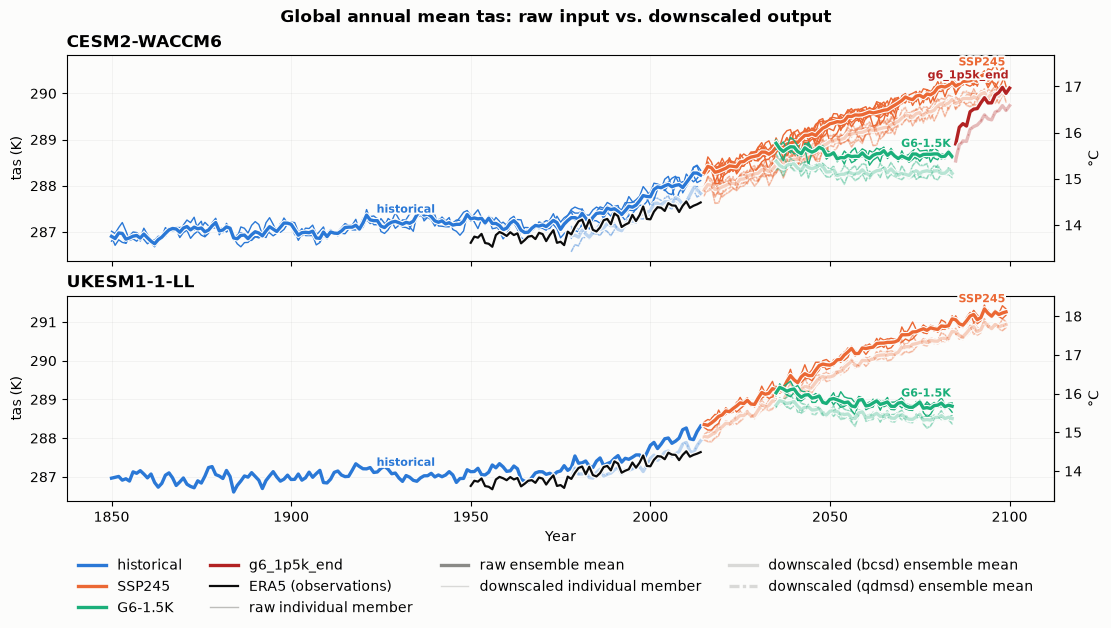

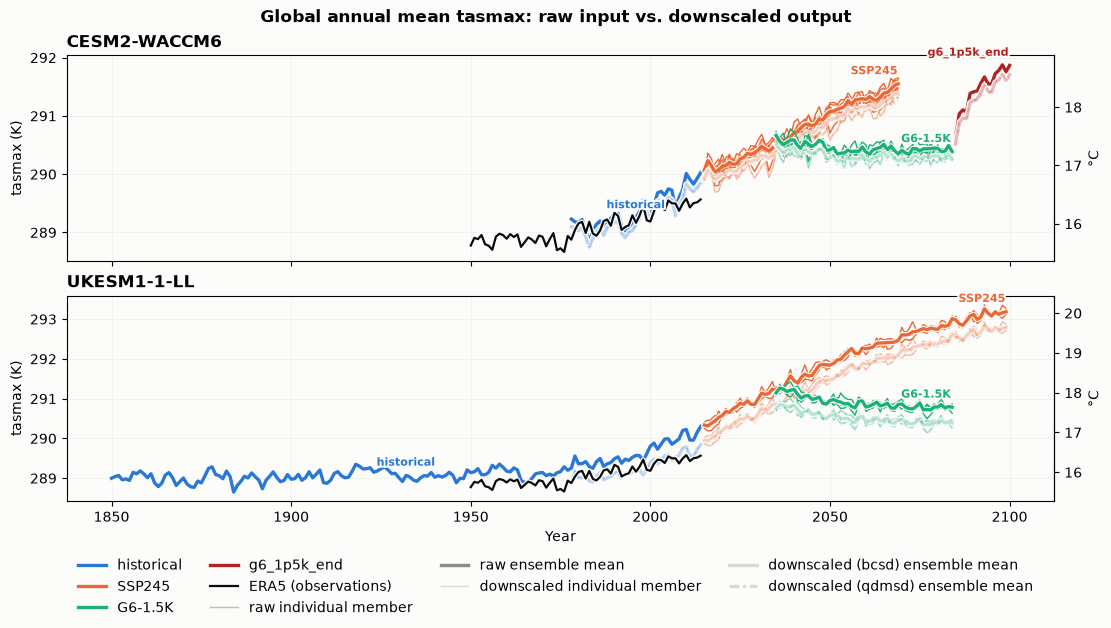

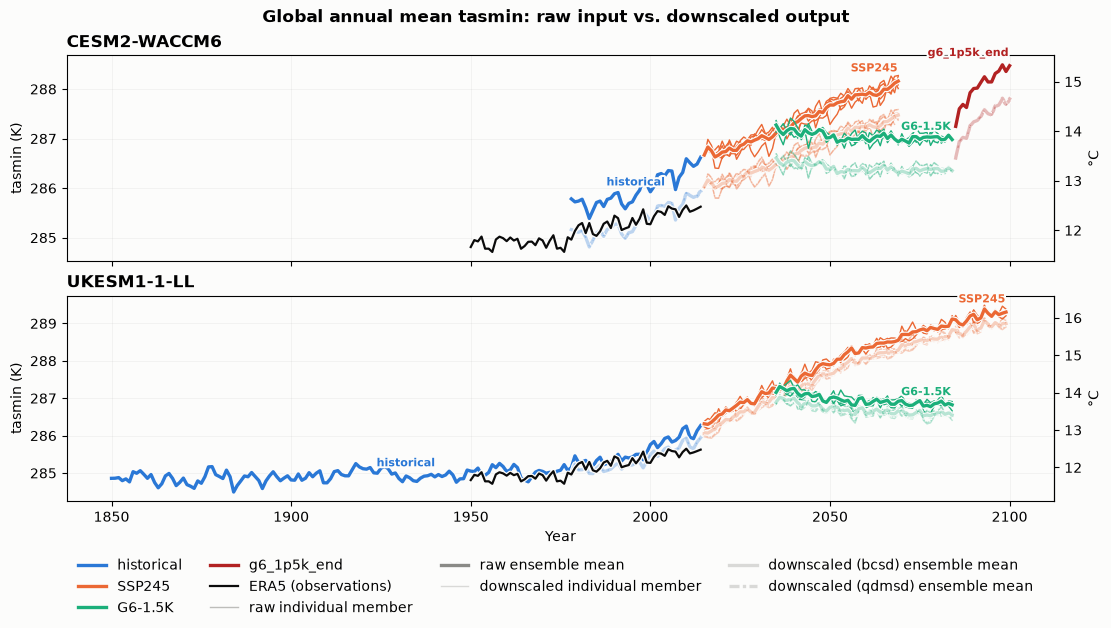

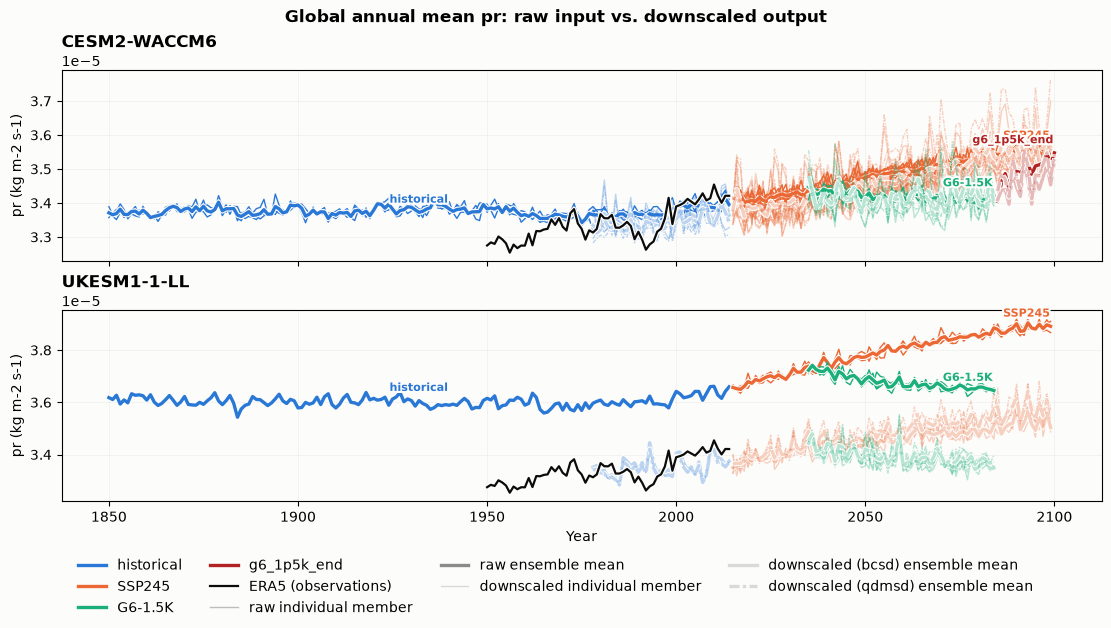

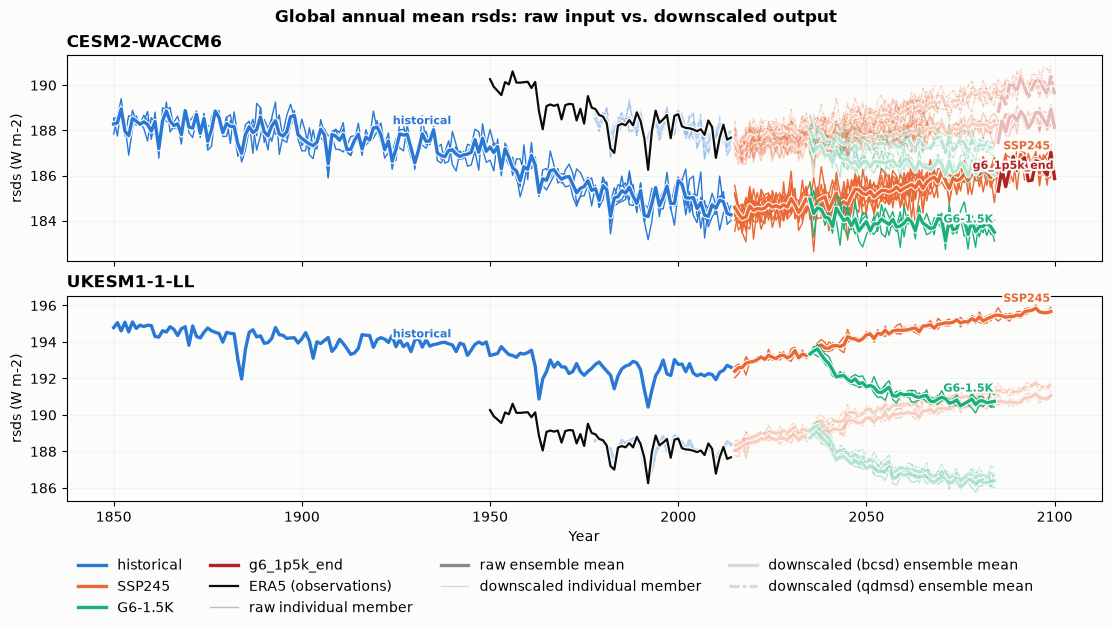

In [11]:
for variable in VARIABLES:
    annual = annual_by_variable[variable]
    downscaled = downscaled_by_variable[variable]
    obs_annual = annual[(annual.gcm == "ERA5") & annual.keep] if INCLUDE_ERA5 else None

    fig, axes = plt.subplots(
        len(GCMS), 1, figsize=(11, 3.1 * len(GCMS)), sharex=True, constrained_layout=True
    )
    # Pin the surface so the figure keeps a light background under a dark docs theme, which the
    # palette was validated against.
    fig.patch.set_facecolor(SURFACE)

    for ax, gcm in zip(axes, GCMS):
        plot_gcm(ax, variable, annual, gcm, obs=obs_annual, downscaled_df=downscaled)

    axes[-1].set_xlabel("Year")
    fig.legend(
        handles=legend_handles(annual),
        loc="outside lower center",
        ncol=4,
        frameon=False,
    )
    fig.suptitle(
        f"Global annual mean {variable}: raw input vs. downscaled output", fontweight="bold"
    )
    plt.show()

### 4.1 The scenario junctions

Zoomed to 1995-2050, where both junctions sit. Only the 2015 handover should be seamless: SAI
deployment begins at 2035, so a change of slope there is the experiment working as intended.

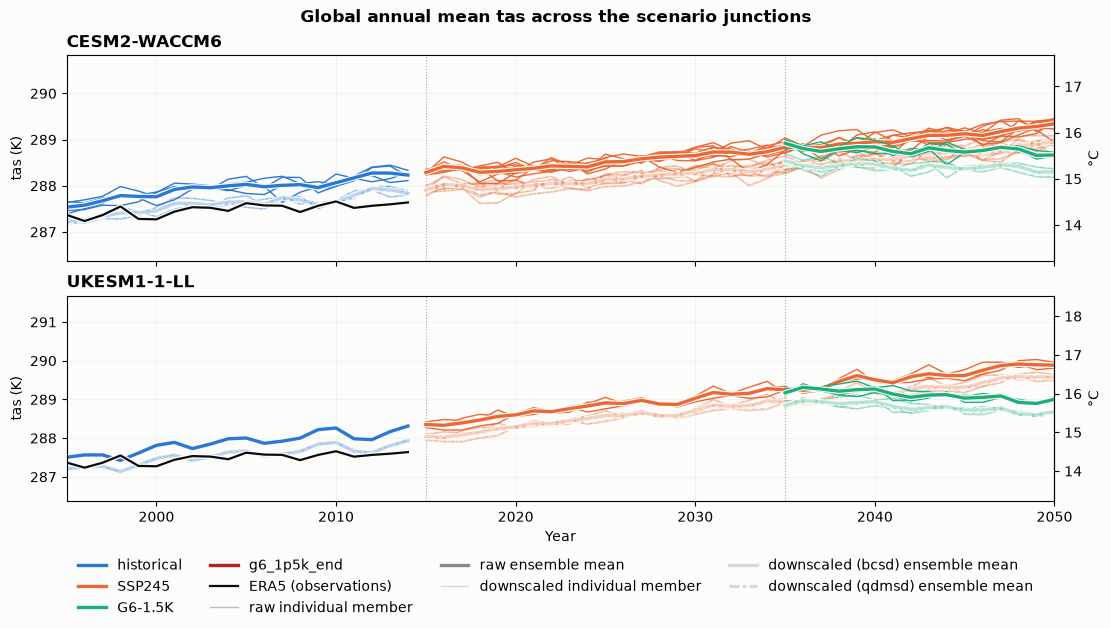

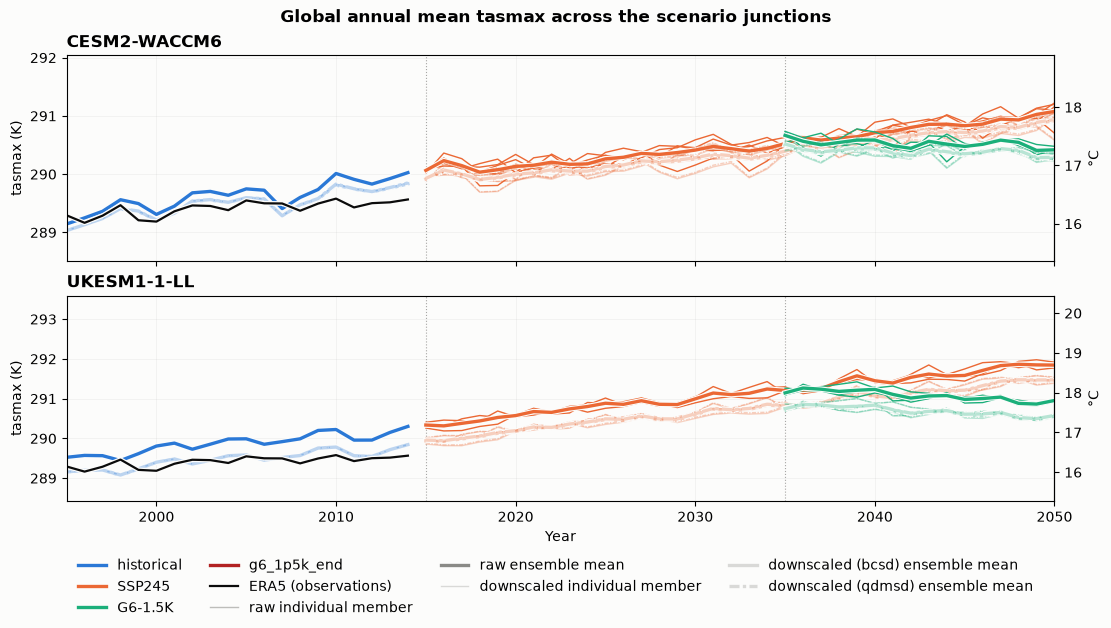

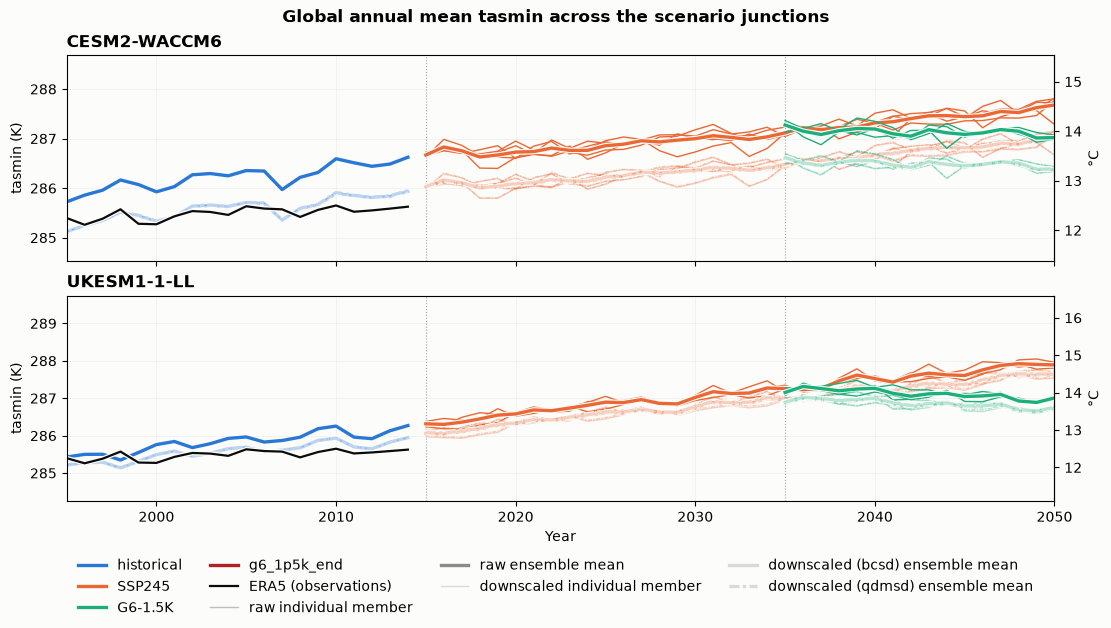

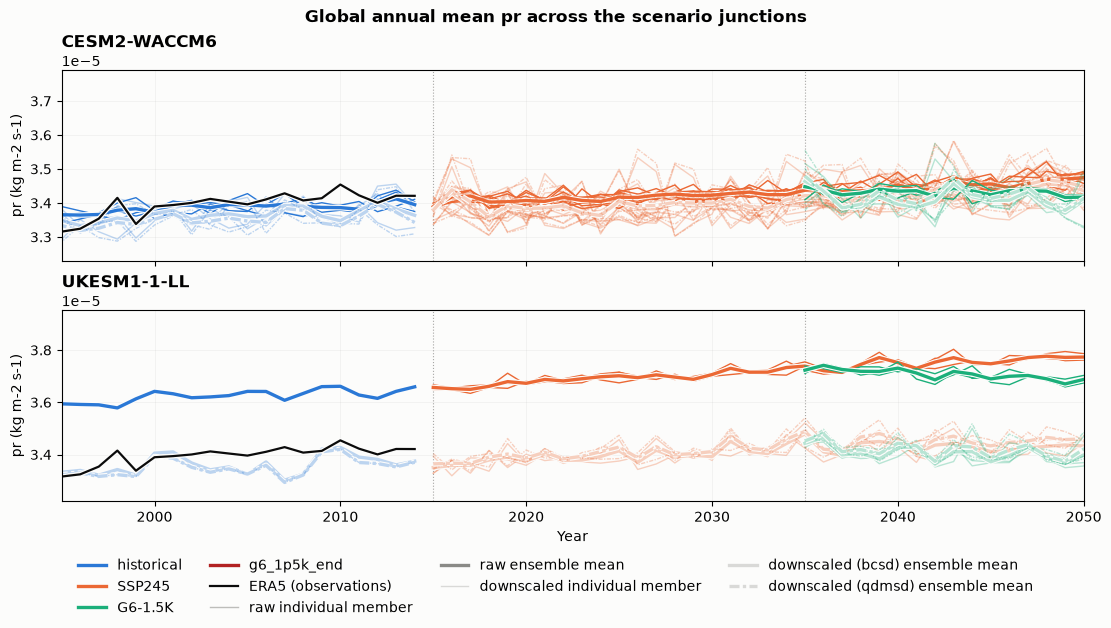

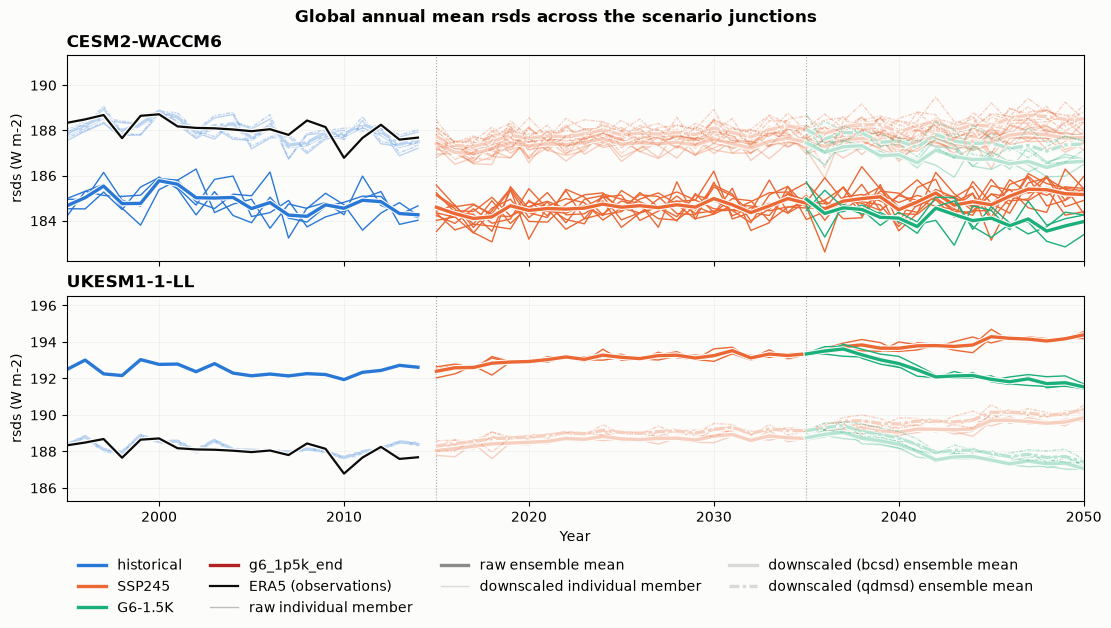

In [12]:
for variable in VARIABLES:
    annual = annual_by_variable[variable]
    downscaled = downscaled_by_variable[variable]
    obs_annual = annual[(annual.gcm == "ERA5") & annual.keep] if INCLUDE_ERA5 else None

    fig, axes = plt.subplots(
        len(GCMS), 1, figsize=(11, 3.1 * len(GCMS)), sharex=True, constrained_layout=True
    )
    # Pin the surface so the figure keeps a light background under a dark docs theme, which the
    # palette was validated against.
    fig.patch.set_facecolor(SURFACE)

    for ax, gcm in zip(axes, GCMS):
        plot_gcm(
            ax, variable, annual, gcm, obs=obs_annual, downscaled_df=downscaled, label_means=False
        )
        for junction in (2015, 2035):
            ax.axvline(junction, color=INK, lw=0.8, ls=":", alpha=0.5, zorder=0)

    axes[0].set_xlim(1995, 2050)
    axes[-1].set_xlabel("Year")
    fig.legend(handles=legend_handles(annual), loc="outside lower center", ncol=4, frameon=False)
    fig.suptitle(f"Global annual mean {variable} across the scenario junctions", fontweight="bold")
    plt.show()

## 5. Downscaled output, all models overlaid

The figures above put GCM on the panel axis and scenario on color, so comparing models directly
means comparing across panels. This section swaps that: **scenario becomes the panel**, and every
GCM is drawn together on it in its own color, so the models are directly comparable within a
single axes. Both rows draw the same thin-member/thick-ensemble-mean pair as section 4, just
re-colored by GCM instead of scenario; method (bcsd vs qdmsd) is still distinguished by linestyle,
same `METHOD_LINESTYLE` as above. The raw-GCM member lines and ensemble mean are stacked in a
second row underneath, same color-per-GCM convention and the same y-axis, as a direct visual check
on how much the downscaled row differs from its raw input.

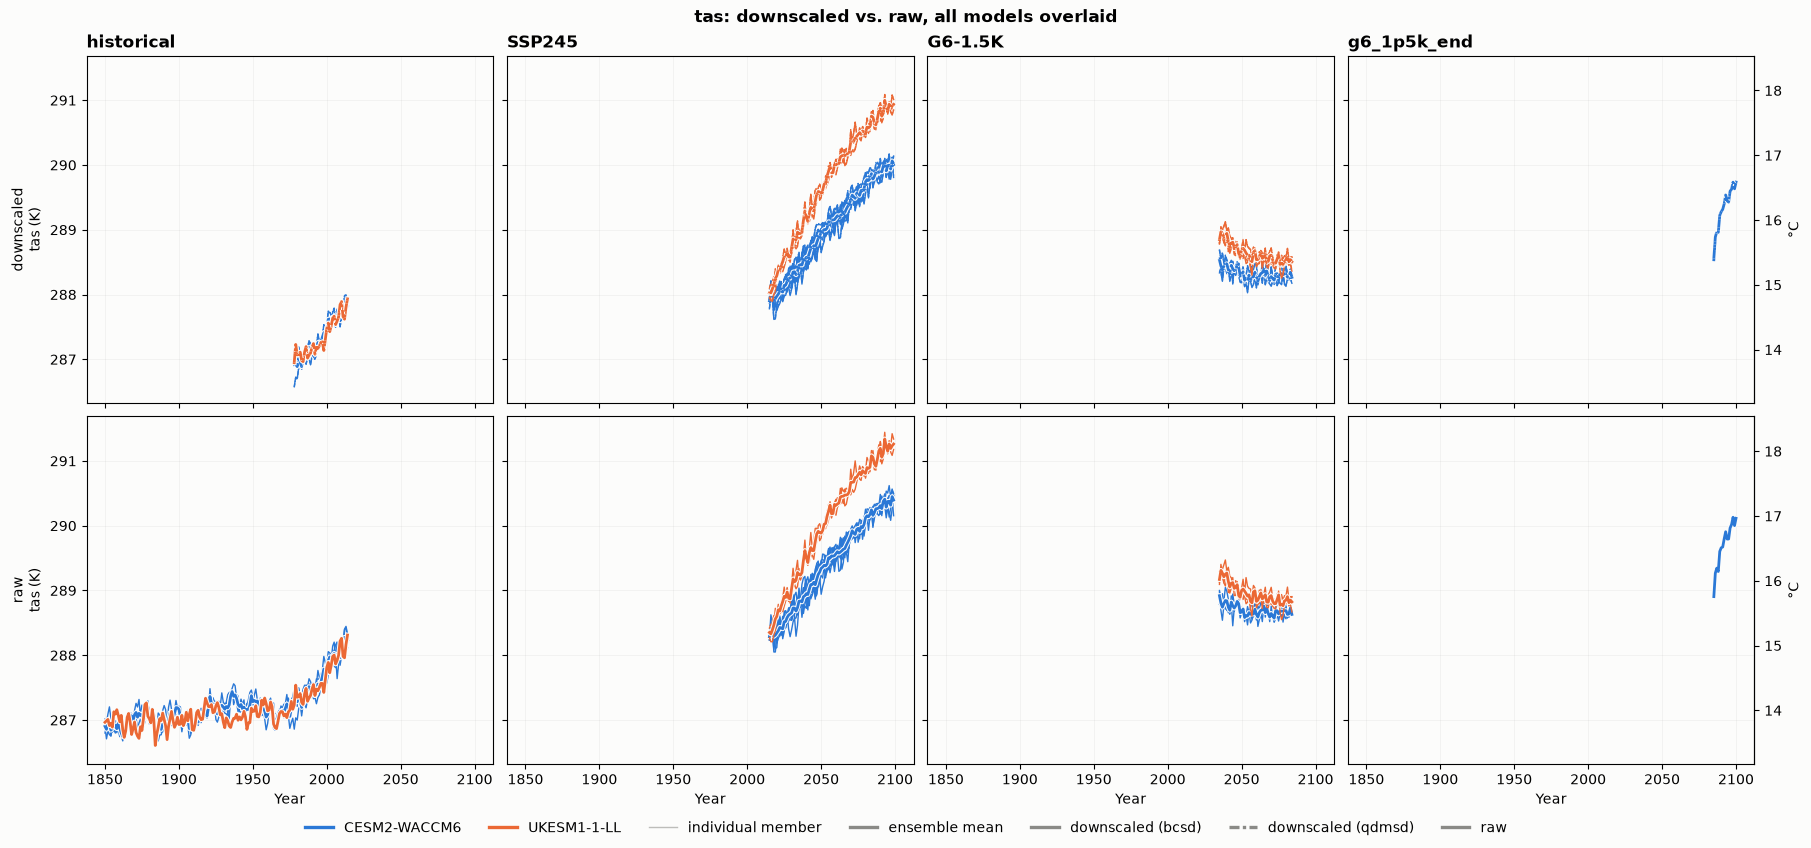

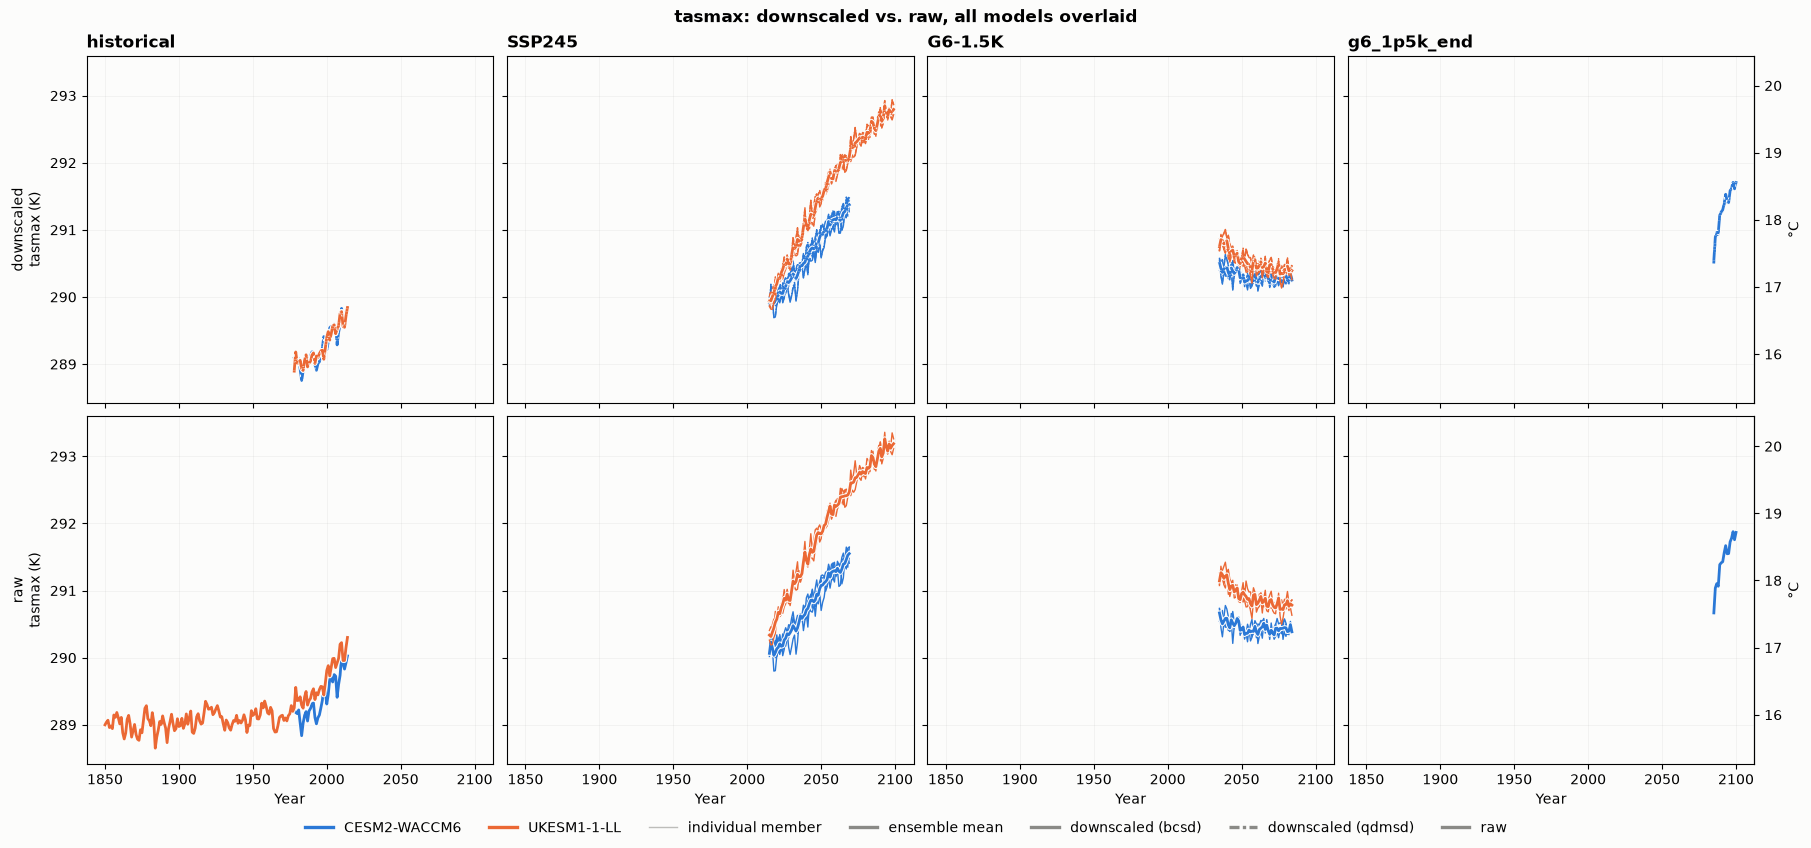

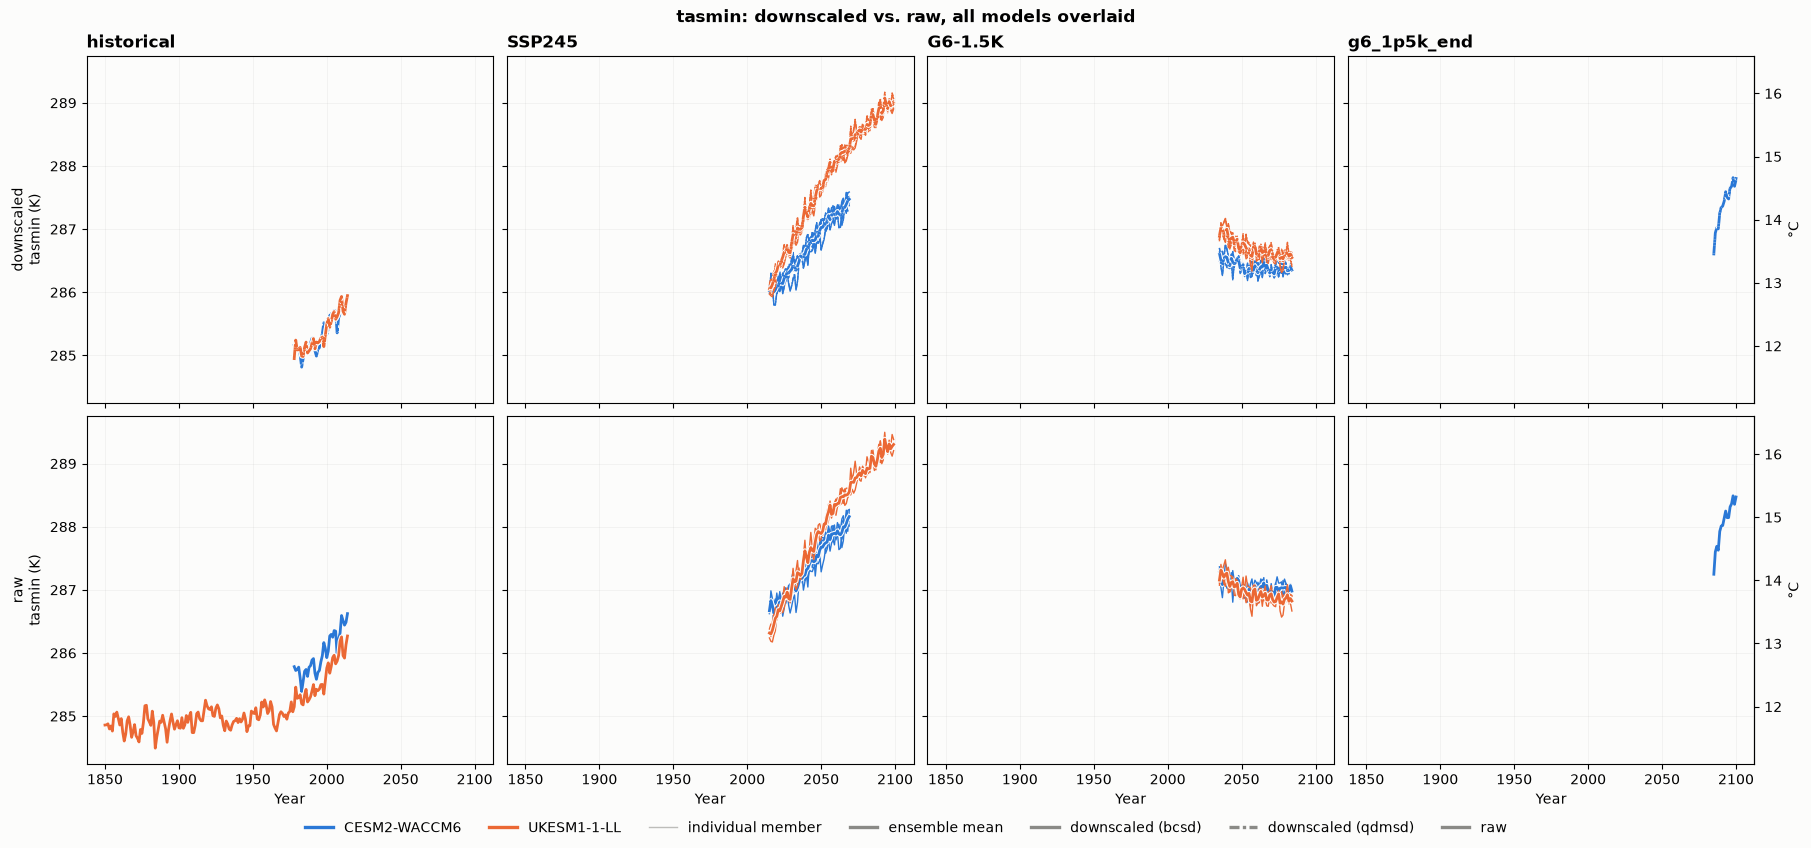

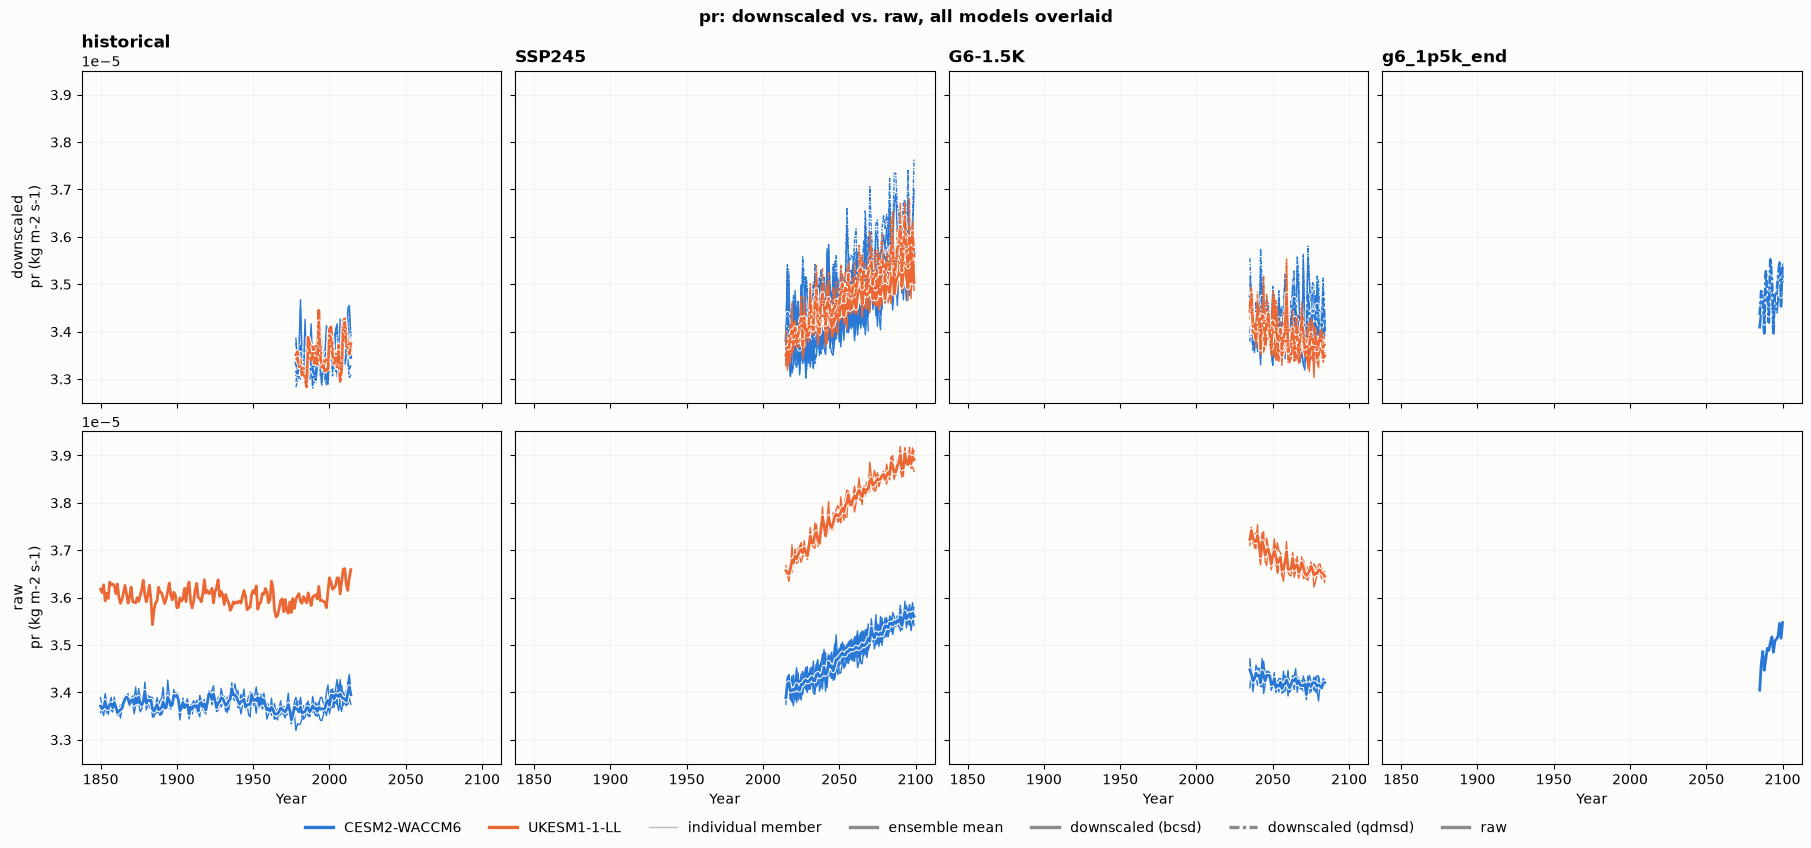

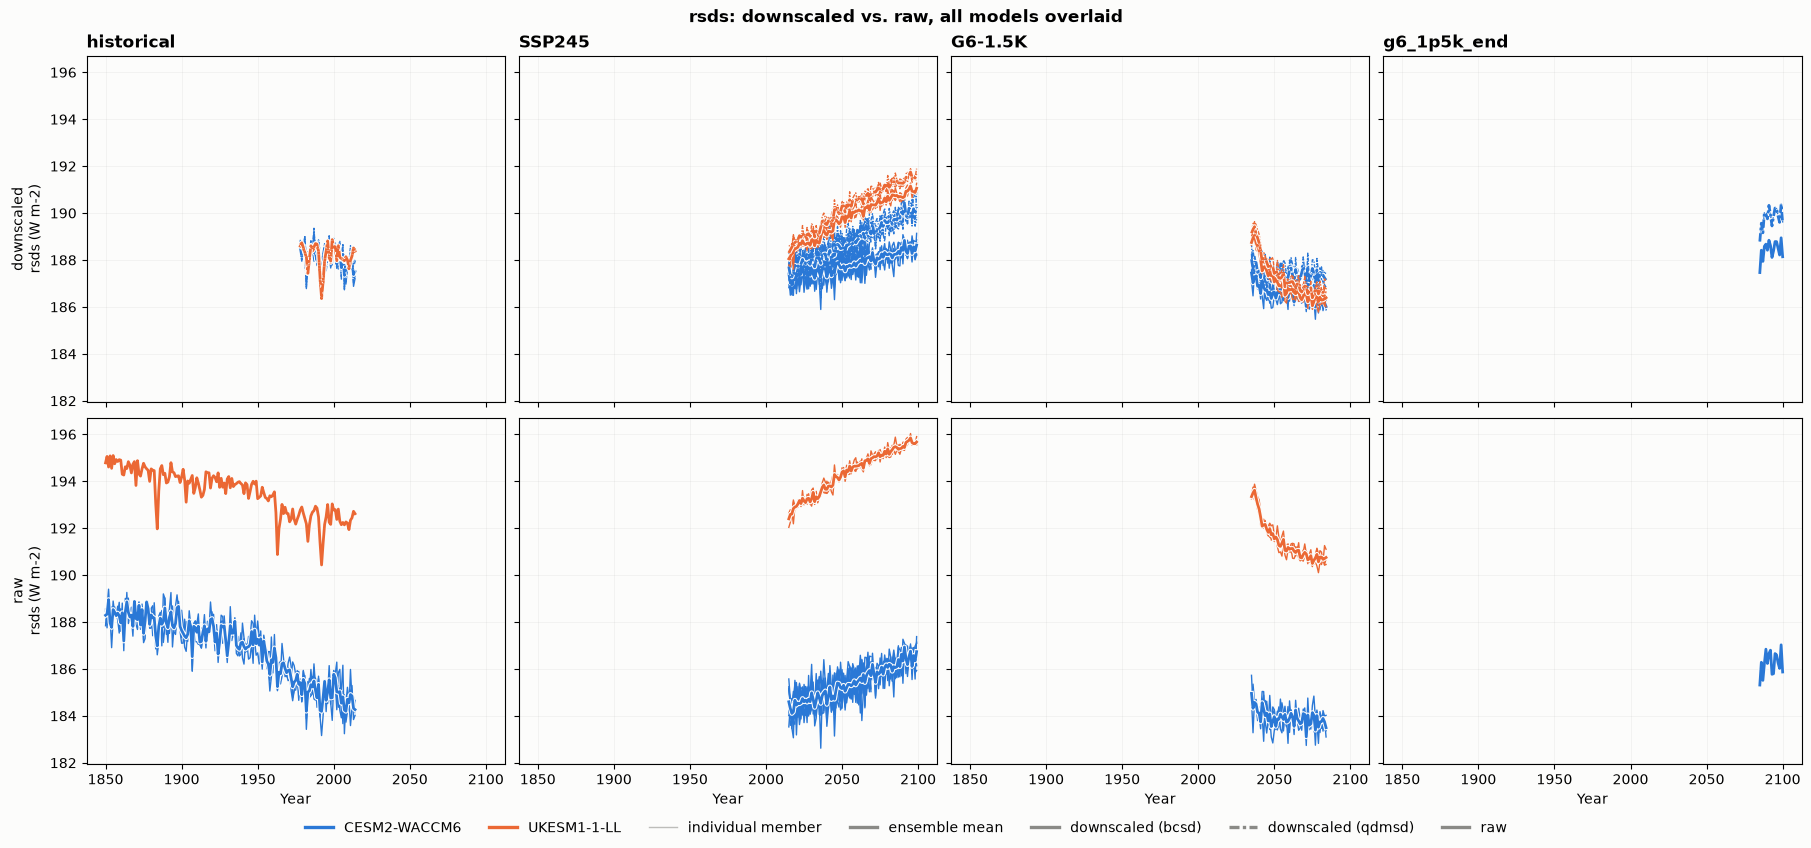

In [13]:
# A separate palette from SCENARIO_STYLE, reused here for a different meaning (GCM, not
# scenario) -- fine since this section's figures never encode scenario by color (scenario is the
# panel axis instead), so there's no risk of the same color meaning two things on one figure.
GCM_COLOR = {
    "CESM2-WACCM6": "#2a78d6",
    "UKESM1-1-LL": "#eb6834",
}


def plot_across_gcms(
    variable: str, downscaled_df: pd.DataFrame, raw_df: pd.DataFrame | None = None
) -> None:
    """One figure per variable: one column per scenario, every GCM overlaid in its own color.

    Deliberately swaps plot_gcm's panel/color axes -- panel=GCM, color=scenario there; here,
    panel=scenario, color=GCM -- since the comparison this section is for is models against each
    other, which needs GCM on the channel that puts multiple series in the same axes (color), not
    the one that puts them in separate axes (panel).

    Both rows draw the same thin-member/thick-ensemble-mean pair `plot_gcm` uses (one thin line
    per `ensemble_member`, one ringed thick line for the across-member mean), just re-colored by
    GCM instead of scenario. Unlike `plot_gcm`, there's no DOWNSCALED_ALPHA fade here: raw and
    downscaled never share an axes in this section (top row is downscaled, bottom is raw), so
    there's nothing for one family to occlude in the other, and both draw at full opacity.

    If `raw_df` is given, a second row is added underneath with the raw-GCM member lines and
    ensemble mean (same GCM colors, no method dimension to distinguish since raw has none),
    sharing the top row's y-axis -- absolute values, so a variable's scenarios stay in a
    comparable range across rows, making "how far did downscaling move this from its raw input"
    a direct visual read rather than something to eyeball across two separately-scaled figures.
    """
    scenarios_present = [
        g
        for g in GROUPS
        if ((downscaled_df.group == g) & downscaled_df.keep).any()
        or (raw_df is not None and ((raw_df.group == g) & raw_df.keep).any())
    ]
    if not scenarios_present:
        print(f"{variable}: no data to plot")
        return

    nrows = 2 if raw_df is not None else 1
    fig, axes = plt.subplots(
        nrows,
        len(scenarios_present),
        figsize=(4.5 * len(scenarios_present), 4.2 * nrows),
        sharey=True,
        sharex=True,
        constrained_layout=True,
        squeeze=False,
    )
    fig.patch.set_facecolor(SURFACE)

    for col, scenario in enumerate(scenarios_present):
        ax = axes[0, col]
        for gcm in GCMS:
            for method in METHODS:
                subset = downscaled_df[
                    (downscaled_df.gcm == gcm)
                    & (downscaled_df.group == scenario)
                    & (downscaled_df.method == method)
                    & downscaled_df.keep
                ]
                if subset.empty:
                    continue

                # Thin per-member lines, same "one line per ensemble_member" grouping plot_gcm
                # uses on the raw side, just colored by GCM instead of scenario.
                for _, member in subset.groupby("ensemble_member"):
                    member = member.sort_values("year")
                    ax.plot(
                        member.year,
                        member["mean"],
                        color=GCM_COLOR[gcm],
                        linestyle=METHOD_LINESTYLE[method],
                        lw=1.0,
                        alpha=1,
                    )

                ensemble = subset.groupby("year")["mean"].mean().sort_index()
                ax.plot(
                    ensemble.index,
                    ensemble.values,
                    color=GCM_COLOR[gcm],
                    linestyle=METHOD_LINESTYLE[method],
                    lw=2.0,
                    path_effects=ring(3.5),
                )
        ax.set_facecolor(SURFACE)
        ax.set_title(GROUP_TO_SCENARIO.get(scenario, scenario), loc="left", fontweight="bold")
        ax.grid(alpha=0.18, lw=0.5)
        if col == 0:
            ax.set_ylabel(f"downscaled\n{variable} ({VARIABLE_UNITS.get(variable, '')})")

        if raw_df is not None:
            ax_raw = axes[1, col]
            for gcm in GCMS:
                raw_subset = raw_df[(raw_df.gcm == gcm) & (raw_df.group == scenario) & raw_df.keep]
                if raw_subset.empty:
                    continue

                for _, member in raw_subset.groupby("ensemble_member"):
                    member = member.sort_values("year")
                    ax_raw.plot(member.year, member["mean"], color=GCM_COLOR[gcm], lw=1.0, alpha=1)

                ensemble = raw_subset.groupby("year")["mean"].mean().sort_index()
                ax_raw.plot(
                    ensemble.index,
                    ensemble.values,
                    color=GCM_COLOR[gcm],
                    lw=2.0,
                    path_effects=ring(3.5),
                )
            ax_raw.set_facecolor(SURFACE)
            ax_raw.grid(alpha=0.18, lw=0.5)
            ax_raw.set_xlabel("Year")
            if col == 0:
                ax_raw.set_ylabel(f"raw\n{variable} ({VARIABLE_UNITS.get(variable, '')})")
        else:
            ax.set_xlabel("Year")

    if variable in TEMPERATURE_VARIABLES:
        add_celsius_axis(axes[0, -1])
        if raw_df is not None:
            add_celsius_axis(axes[1, -1])

    handles = [Line2D([], [], color=GCM_COLOR[gcm], lw=2.4, label=gcm) for gcm in GCMS]
    handles += [
        Line2D([], [], color=STATUS_NEUTRAL, lw=1.0, alpha=0.55, label="individual member"),
        Line2D([], [], color=STATUS_NEUTRAL, lw=2.4, label="ensemble mean"),
    ]
    handles += [
        Line2D(
            [],
            [],
            color=STATUS_NEUTRAL,
            lw=2.4,
            linestyle=METHOD_LINESTYLE[method],
            label=f"downscaled ({method})",
        )
        for method in METHODS
    ]
    if raw_df is not None:
        handles.append(Line2D([], [], color=STATUS_NEUTRAL, lw=2.4, linestyle="-", label="raw"))
    fig.legend(handles=handles, loc="outside lower center", ncol=len(handles), frameon=False)
    title = (
        f"{variable}: downscaled vs. raw, all models overlaid"
        if raw_df is not None
        else f"Downscaled {variable}, all models overlaid"
    )
    fig.suptitle(title, fontweight="bold")
    plt.show()


for variable in VARIABLES:
    plot_across_gcms(
        variable, downscaled_by_variable[variable], raw_df=annual_by_variable[variable]
    )

## Shut down the cluster

In [14]:
cluster.shutdown()

[2026-09-10 02:03:26,924][INFO    ][coiled] Cluster 2029556 deleted successfully.
